# Faithfulness Benchmark Shapiq Vision · Captum KernelSHAP
### Which explainer produces the most faithful attributions, across a sweep of images?

We extend our testing to a **faithfulness benchmark** with over ~200 ImageNet images. Both methods reuse the exact same building blocks: same ResNet-18, same SLIC/grid segments, same per-image mean-color baseline, same explained class (the model's own top-1 prediction), and the same evaluation budget, so that any gap in faithfulness reflects the *estimator*, not a difference in setup.

**Faithfulness metric (AID):** for each image/method/config, we rank superpixels by attribution value and trace two curves: an **insertion** curve (confidence as the most-important superpixels are revealed one by one, starting from an all-baseline image) and a **deletion** curve (confidence as the most-important superpixels are removed one by one, starting from the full image). A faithful explainer's insertion curve rises fast and its deletion curve falls fast. AID = area under insertion - area under deletion (higher = better).

**Sections:**
1. **Experiment** - the full sweep. Skipped by default (`RUN_EXPERIMENT = False`); loads precomputed results instead. Set the flag to `True` to recompute.
2. **Results & figures** - loads `aid_sweep_results.pkl` and renders two figures plus a summary table. CPU, runs in seconds.

**Files needed to run this notebook:** `aid_sweep_results.pkl` (precomputed results, required for Section 2 unless the sweep is rerun in Section 1).

## Section 1 - Experiment

All cells in this section are skipped unless `RUN_EXPERIMENT = True`.

- **Images:** ~200 ImageNet validation images, downloaded via `datasets` and sampled deterministically (fixed seed), then cached locally as PNGs. No manifest file needed - the same seed always selects the same images.
- **Segmentation configs:** `superpixels` (SLIC, n≈40) and `grid` (regular grid, n≈100)
- **Resumable:** results are written to `aid_sweep_results.pkl` after every cell, so an interrupted run resumes where it stopped.
- **Runtime:** a full 200-image × 2-method × 2-config sweep is CPU-feasible but slow; a GPU is strongly recommended. `PILOT = True` restricts the sweep to the first `PILOT_N` images for a quick end-to-end check.

In [ ]:
RUN_EXPERIMENT = False   # True: run the full sweep below. False: skip to Section 2 (precomputed results).
PILOT          = True    # True: first PILOT_N images only. False: full sweep.
PILOT_N        = 10

MODELS = ["resnet18", "vit_b_16"]

import os
ROOT       = os.getcwd()
STORE_PATH = os.path.join(ROOT, "data/aid_sweep_results.pkl")
DATA_DIR   = os.path.join(ROOT, "data/images")

In [2]:
if RUN_EXPERIMENT:
    !pip install "git+https://github.com/S2k-1/shapiq.git@feature/protocols" captum datasets --quiet

In [3]:
if RUN_EXPERIMENT:
    import time
    import pickle
    import json
    import traceback
    from datetime import datetime, timedelta

    import numpy as np
    import pandas as pd
    import torch
    from PIL import Image
    from torchvision import models, transforms
    from skimage.segmentation import slic

    from shapiq.vision import CNNArchitecture, ImageExplainer, MeanColorMasking
    from shapiq.vision.players import CustomPlayerStrategy
    from captum.attr import KernelShap

    SEED = 0
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device:", device)

### 1.1 · Load ResNet-18
We make the image match models dataset distribution and load the pretrained Resnet-18

In [ ]:
if RUN_EXPERIMENT:
    MODEL_BUILDERS = {
        "resnet18": (models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1),
        "vit_b_16": (models.vit_b_16, models.ViT_B_16_Weights.IMAGENET1K_V1),
    }

    def load_model(name):
        builder, weights = MODEL_BUILDERS[name]
        net = builder(weights=weights).eval().to(device)
        tfm = weights.transforms()  # resize/crop/normalize matched to this specific model

        # look up the expected resize_size and crop_size, if not there, set to 224 and 256
        crop = tfm.crop_size[0] if hasattr(tfm, "crop_size") else 224
        rsz = tfm.resize_size[0] if hasattr(tfm, "resize_size") else 256
        return {
            "model": net,
            "resize_crop": transforms.Compose([transforms.Resize(rsz), transforms.CenterCrop(crop)]), # transform to match the models training dataset distribution
            "normalize": transforms.Normalize(mean=tfm.mean, std=tfm.std),
            "categories": weights.meta["categories"],
        }

    MODEL_STORE = {name: load_model(name) for name in MODELS}

### 1.2 · Download and select images

Images are sampled deterministically from the HuggingFace ImageNet-1k validation split using a fixed seed, then cached to `data/` as .pngs so the sweep doesn't re-download on every run.

In [ ]:
if RUN_EXPERIMENT:
    from datasets import load_dataset

    N_IMAGES = PILOT_N if PILOT else 200
    DATASET_NAME, DATASET_SPLIT = "benjamin-paine/imagenet-1k-256x256", "validation"

    os.makedirs(DATA_DIR, exist_ok=True)
    ds = load_dataset(DATASET_NAME, split=DATASET_SPLIT)

    # Using a fixed seed ensures that every time you run this notebook, it will select the exact same subset of images
    rng = np.random.default_rng(SEED)
    dataset_indices = rng.choice(len(ds), size=N_IMAGES, replace=False)
    dataset_indices.sort()

    # Checks if the image already exists in your local data/ folder
    # if not, loads it from the HF dataset, ensures it is in RGB format and writes it to disk
    # if it is already there, skips downloading and appends the filename
    image_list = []
    for di in dataset_indices:
        fname = f"img_{di:06d}.png"
        fpath = os.path.join(DATA_DIR, fname)
        if not os.path.exists(fpath):
            img = ds[int(di)]["image"]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(np.array(img))
            img.convert("RGB").save(fpath)
        image_list.append(fname)

    print(f"{'PILOT' if PILOT else 'FULL'}: {len(image_list)} images selected")

### 1.3 · Segmentation configs and shared sweep settings

We get the superpixels/grid and define the method. Budget scales with the number of players (`budget_for`) so the ~40-player and ~100-player configs get a comparable number of samples per player, rather than a single fixed budget that would favor whichever config has fewer players.

In [ ]:
if RUN_EXPERIMENT:
    def superpixel_segments(image_np, n_segments):
        return slic(image_np, n_segments=n_segments, compactness=10, sigma=1, start_label=0)

    def grid_segments(image_np, n_segments):
        h, w = image_np.shape[:2]
        n_side = int(round(np.sqrt(n_segments)))
        row_edges = np.linspace(0, h, n_side + 1).astype(int)
        col_edges = np.linspace(0, w, n_side + 1).astype(int)
        seg = np.zeros((h, w), dtype=np.int64)
        idx = 0
        for r in range(n_side):
            for c in range(n_side):
                seg[row_edges[r]:row_edges[r + 1], col_edges[c]:col_edges[c + 1]] = idx
                idx += 1
        return seg

    SEGMENTERS  = {"superpixels": superpixel_segments, "grid": grid_segments}
    SEG_CONFIGS = [("superpixels", 40), ("grid", 100)]
    METHODS     = ["shapiq_vision", "kernel_shap"]

    MAX_ORDER  = 1
    INDEX      = "SV"

    def budget_for(n_seg):
        return max(200, 8 * n_seg)

### 1.4 · Per-image, per-method attribution runners

Each function takes the *same* prepared image (tensor, mean baseline, segments) and returns per-superpixel values plus timing/call-count.

In [7]:
if RUN_EXPERIMENT:
    def run_shapiq_vision(image_np, segments, n_players, target_class, budget, net, normalize):
        class CountedModel(torch.nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model
                self.n_calls = 0

            def forward(self, x):
                self.n_calls += x.shape[0]
                return self.model(normalize(x))

        counted_model = CountedModel(net).eval().to(device)
        architecture = CNNArchitecture(
            model=counted_model,
            masking_strategy=MeanColorMasking(),
            player_strategy=CustomPlayerStrategy(segments),
        )
        explainer = ImageExplainer(
            model=architecture, data=image_np, class_index=target_class,
            index=INDEX, max_order=MAX_ORDER, random_state=SEED,
        )
        t0 = time.time()
        iv = explainer.explain(budget=budget)
        elapsed = time.time() - t0
        values = iv.get_n_order_values(1)
        return values, elapsed, counted_model.n_calls


    def run_kernel_shap(tensor_image, baseline, seg_t, segments, n_players, target_class, budget, net):
        feature_mask = seg_t.long().unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
        call_count = [0]

        def _counted_model(x):
            call_count[0] += x.shape[0]
            return net(x)

        ks = KernelShap(_counted_model)
        t0 = time.time()
        attributions = ks.attribute(
            inputs=tensor_image, baselines=baseline, target=target_class,
            feature_mask=feature_mask, n_samples=budget,
        )
        elapsed = time.time() - t0
        attr_np = attributions[0, 0].detach().cpu().numpy()
        values = np.array([attr_np[segments == i].mean() for i in range(n_players)])
        return values, elapsed, call_count[0]


    RUNNERS = {
        "shapiq_vision": lambda ctx: run_shapiq_vision(ctx["image_np"], ctx["segments"], ctx["n_players"], ctx["target_class"], ctx["budget"], ctx["model"], ctx["normalize"]),
        "kernel_shap":   lambda ctx: run_kernel_shap(ctx["tensor_image"], ctx["baseline"], ctx["seg_t"], ctx["segments"], ctx["n_players"], ctx["target_class"], ctx["budget"], ctx["model"]),
    }

### 1.5 · Insertion/deletion faithfulness (AID)

Superpixels are ranked by attribution value, most important first. The insertion curve starts from an all-baseline image and reveals superpixels in that order; the deletion curve starts from the full image and removes them in that order. Both curves are computed as one batched forward pass per curve rather than one call per step, since that's the expensive part of the sweep.

In [ ]:
if RUN_EXPERIMENT:
    def confidence_curve(tensor_image, baseline, seg_t, order, target_class, mode, net, batch_size=32):
        ''' If an image has n superpixels, the loop runs n+1 times (from 0 to n):
        Step 0: Represents the starting state (completely empty/baseline for Insertion; fully intact for Deletion)
        Steps 1 to n: Progressively reveals (or deletes) one superpixel at a time based on the importance ranking '''
        n = len(order)
        masks = []
        for step in range(n + 1):
            if mode == "insertion":
                active_ids = order[:step]
            else:
                removed = set(order[:step].tolist())
                active_ids = [i for i in range(n) if i not in removed]
            if len(active_ids) == 0:
                mask = torch.zeros_like(seg_t, dtype=torch.bool)
            else:
                active_t = torch.as_tensor(np.array(active_ids).copy(), device=device)
                mask = torch.isin(seg_t, active_t) # if superpixel ID is in active_t, it becomes True, otherwise its False
            masks.append(mask)
        masks = torch.stack(masks)

        # for every pixel: if the mask is True, it takes the pixel from the original image
        # if False, it takes it from the baseline. This outputs a single large tensor of shape (n + 1, 3, 224, 224).
        imgs = torch.where(masks.unsqueeze(1), tensor_image, baseline)

        probs = []
        with torch.no_grad():
            for i in range(0, imgs.shape[0], batch_size):
                batch = imgs[i:i + batch_size]      # Loops through n+1 stacked images in chunks of size batch_size
                out = torch.softmax(net(batch), dim=1)[:, target_class]
                probs.append(out.cpu().numpy())
        return np.concatenate(probs)


    def aid_score(insertion_curve, deletion_curve):
        x = np.linspace(0, 1, len(insertion_curve))
        # trapezoidal rule approximates the area under discrete points by drawing a straight line between each neighboring pair of scores
        return float(np.trapezoid(insertion_curve, x) - np.trapezoid(deletion_curve, x)) 

### 1.6 · The sweep

For every image × segmentation config × method: build the segments and per-image mean baseline, get the model's top-1 class, run the method, then score it with AID. Results are appended to `aid_sweep_results.pkl` after every cell so the sweep is resumable.

In [ ]:
if RUN_EXPERIMENT:
    # baseline_type and class_rank are fixed for now ("average" baseline, top-1 class)
    # but kept as explicit key fields so the store can support sweeping over them later
    BASELINE_TYPE = "average"
    CLASS_RANK = 0

    def key_of(image, model_name, method, seg, n_seg):
        return (image, model_name, method, seg, n_seg, BASELINE_TYPE, CLASS_RANK)

    if os.path.exists(STORE_PATH):
        with open(STORE_PATH, "rb") as f:
            STORE = pickle.load(f)
    else:
        STORE = {}
    print(len(STORE), "cells in store")

    def save_store():
        tmp = STORE_PATH + ".tmp"
        with open(tmp, "wb") as f:
            pickle.dump(STORE, f)
        os.replace(tmp, STORE_PATH)

    configs_to_run = [
        (img, model_name, method, seg, n_seg)
        for model_name in MODELS
        for img in image_list
        for seg, n_seg in SEG_CONFIGS
        for method in METHODS
    ]
    todo = [c for c in configs_to_run if key_of(*c) not in STORE]
    print(f"{len(configs_to_run)} cells | {len(todo)} to compute")

    failures, durations = [], []
    for k_idx, (img, model_name, method, seg, n_seg) in enumerate(todo):
        t0 = time.time()
        label = f"{img}|{model_name}|{method:<13}|{seg}|n={n_seg}"
        try:
            mcfg = MODEL_STORE[model_name]
            net, resize_crop, normalize = mcfg["model"], mcfg["resize_crop"], mcfg["normalize"]

            pil_image = Image.open(os.path.join(DATA_DIR, img)).convert("RGB")
            resized_image = resize_crop(pil_image)
            image_np = np.array(resized_image)
            tensor_image = normalize(transforms.ToTensor()(resized_image)).unsqueeze(0).to(device)

            with torch.no_grad():
                probs_full = torch.softmax(net(tensor_image), dim=1)[0]
            target_class = int(torch.argmax(probs_full).item())

            spatial_dims = tuple(range(tensor_image.ndim - 2, tensor_image.ndim))
            baseline = tensor_image.mean(dim=spatial_dims, keepdim=True).expand_as(tensor_image)

            segments = SEGMENTERS[seg](image_np, n_seg)
            n_players = int(segments.max()) + 1
            seg_t = torch.from_numpy(segments).to(device)
            budget = budget_for(n_players)

            ctx = dict(image_np=image_np, tensor_image=tensor_image, baseline=baseline,
                       segments=segments, seg_t=seg_t, n_players=n_players,
                       target_class=target_class, budget=budget, model=net, normalize=normalize)
            values, elapsed, n_calls = RUNNERS[method](ctx)

            order = np.argsort(values)[::-1]
            insertion_curve = confidence_curve(tensor_image, baseline, seg_t, order, target_class, "insertion", net)
            deletion_curve  = confidence_curve(tensor_image, baseline, seg_t, order, target_class, "deletion", net)
            aid = aid_score(insertion_curve, deletion_curve)

            STORE[key_of(img, model_name, method, seg, n_seg)] = {
                "aid": aid, "insertion_curve": insertion_curve, "deletion_curve": deletion_curve,
                "values": values.tolist(), "n_players": n_players,
                "target_class": target_class, "elapsed": elapsed, "n_calls": n_calls,
            }
            save_store()
            dt = time.time() - t0
            durations.append(dt)
            eta = datetime.now() + timedelta(seconds=np.mean(durations) * (len(todo) - k_idx - 1))
            print(f"{k_idx}) {label:<55} {dt:5.1f}s AID={aid:+.3f}")
        except Exception as e:
            failures.append((label, repr(e)))
            print(f"{k_idx}) {label:<55} FAILED: {e!r}")
            traceback.print_exc(limit=2)

    print(f"\ndone - {len(todo) - len(failures)} ok, {len(failures)} failed")
    for l, e in failures:
        print("  FAILED", l, e)

## Section 2 - Results & figures

Loads `aid_sweep_results.pkl` and renders three figures plus a summary table. Doesn't require the model, GPU, or any of the packages installed in Section 1.

In [10]:
import os, pickle
import numpy as np

assert os.path.exists(STORE_PATH), "aid_sweep_results.pkl missing - run Section 1 or provide the precomputed file"
with open(STORE_PATH, "rb") as f:
    STORE = pickle.load(f)
print(f"store: {len(STORE)} cells")

store: 1600 cells


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for k, v in STORE.items():
    image, model_name, method, seg, n_seg, baseline_type, class_rank = k
    rows.append({
        "image": image, "model": model_name, "method": method,
        "segmentation": seg, "n_segments": n_seg,
        "baseline_type": baseline_type, "class_rank": class_rank,
        "aid": v["aid"],
    })
df = pd.DataFrame(rows)

METHODS = ["shapiq_vision", "kernel_shap"]
MODELS  = sorted(df["model"].unique())
missing = [m for m in METHODS if m not in df.method.unique()]
assert not missing, f"store is missing methods: {missing}"

COLOR = {"shapiq_vision": "#2E6FDB", "proxyshap": "#2CA02C", "kernel_shap": "#E8871E"}
LABEL = {"shapiq_vision": "Shapiq Vision", "proxyshap": "ProxySHAP", "kernel_shap": "Captum KernelSHAP"}
HERO_SEG, HERO_N = "superpixels", 40

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(df.groupby(["model", "method"]).aid.agg(["count", "mean"]).round(3))

                        count   mean
model    method                     
resnet18 kernel_shap      400  0.473
         shapiq_vision    400  0.532
vitb16   kernel_shap      400  0.470
         shapiq_vision    400  0.559


### Plot 1 - headline insertion/deletion curves

Curves have a different number of steps per image (segment counts vary slightly per SLIC run), so each curve is interpolated onto a common 0-1 "fraction of segments" grid before averaging. Band = interquartile range.

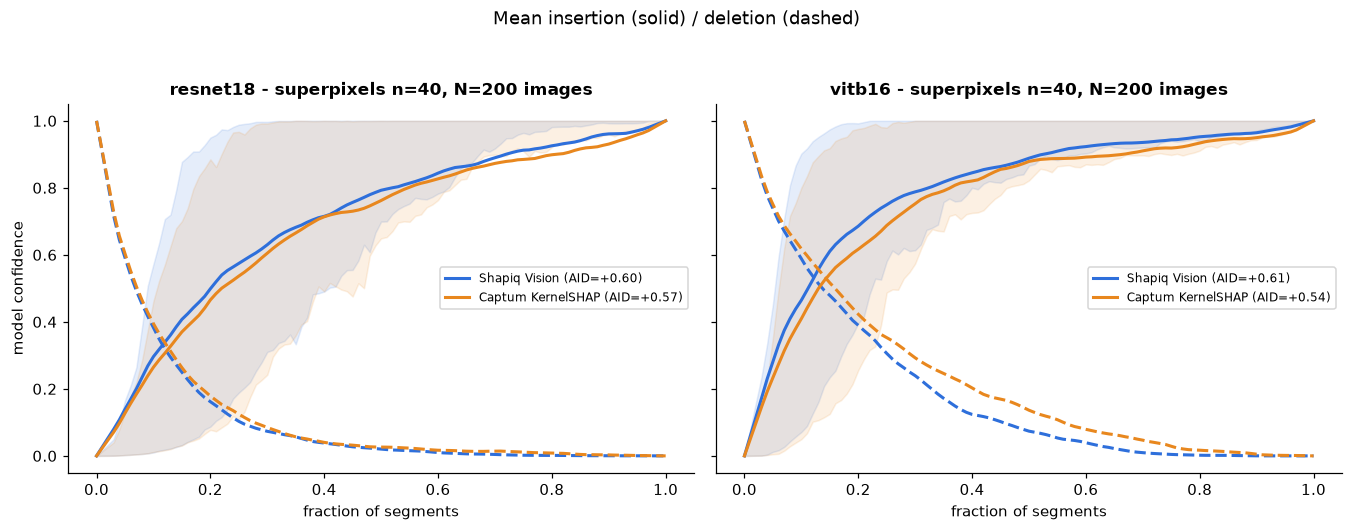

In [12]:
GRID = np.linspace(0, 1, 101)

def interp_curves(curves):
    out = []
    for c in curves:
        c = np.asarray(c, dtype=float)
        out.append(np.interp(GRID, np.linspace(0, 1, len(c)), c))
    return np.vstack(out)

def curves_for(method, seg, n_seg, which, model_name):
    return [v[which] for k, v in STORE.items() if k[1] == model_name and k[2] == method and k[3] == seg and k[4] == n_seg]

fig, axes = plt.subplots(1, len(MODELS), figsize=(6.2 * len(MODELS), 4.6), sharey=True)
axes = np.atleast_1d(axes)

for ax, model_name in zip(axes, MODELS):
    for method in METHODS:
        ins = interp_curves(curves_for(method, HERO_SEG, HERO_N, "insertion_curve", model_name))
        dele = interp_curves(curves_for(method, HERO_SEG, HERO_N, "deletion_curve", model_name))
        aid = df.query("model == @model_name and method == @method and segmentation == @HERO_SEG and n_segments == @HERO_N").aid.mean()
        ax.plot(GRID, ins.mean(0), color=COLOR[method], lw=2, label=f"{LABEL[method]} (AID={aid:+.2f})")
        ax.fill_between(GRID, np.percentile(ins, 25, 0), np.percentile(ins, 75, 0), color=COLOR[method], alpha=0.12)
        ax.plot(GRID, dele.mean(0), color=COLOR[method], lw=2, ls="--")

    n_imgs = df.query("model == @model_name").image.nunique()
    ax.set_xlabel("fraction of segments")
    ax.set_title(f"{model_name} - {HERO_SEG} n={HERO_N}, N={n_imgs} images", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

axes[0].set_ylabel("model confidence")
fig.suptitle("Mean insertion (solid) / deletion (dashed)", y=1.04)
plt.tight_layout()
plt.show()

### Plot 2 - per-image AID agreement

One dot per image, one panel per method pair. Dots on the diagonal mean the two methods scored that image identically. Best- and worst-agreement images are annotated per pair.

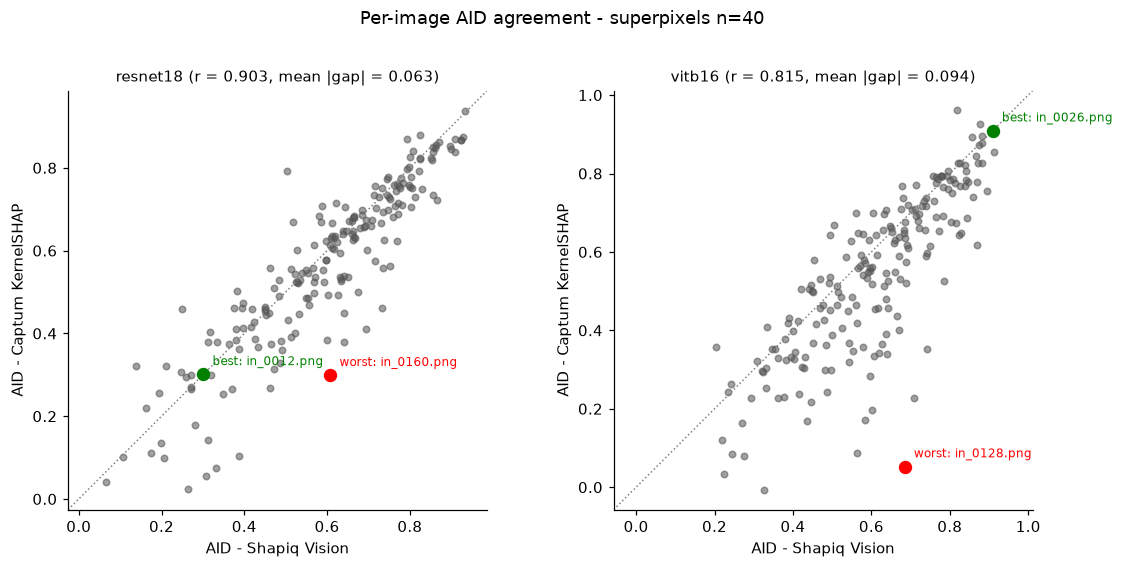

In [16]:
from itertools import combinations

pairs = list(combinations(METHODS, 2))
fig, axes = plt.subplots(len(pairs), len(MODELS), figsize=(5.4 * len(MODELS), 5 * len(pairs)), squeeze=False)

for row, (m1, m2) in enumerate(pairs):
    for col, model_name in enumerate(MODELS):
        ax = axes[row][col]
        sub = df.query("model == @model_name and segmentation == @HERO_SEG and n_segments == @HERO_N")
        piv = sub.pivot_table(index="image", columns="method", values="aid").dropna()
        x, y = piv[m1], piv[m2]

        lim = [min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05]
        ax.plot(lim, lim, color="grey", lw=1, ls=":")
        ax.scatter(x, y, s=18, alpha=0.55, color="#555")

        gap = (x - y).abs()
        for tag, img, col_ in [("best", gap.idxmin(), "green"), ("worst", gap.idxmax(), "red")]:
            ax.scatter(x[img], y[img], s=60, color=col_, zorder=3)
            ax.annotate(f"{tag}: {img}", (x[img], y[img]), fontsize=8, xytext=(6, 6), textcoords="offset points", color=col_)

        r = np.corrcoef(x, y)[0, 1]
        ax.set_title(f"{model_name} (r = {r:.3f}, mean |gap| = {gap.mean():.3f})", fontsize=10)
        ax.set_xlabel(f"AID - {LABEL[m1]}")
        ax.set_ylabel(f"AID - {LABEL[m2]}")
        ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")

fig.suptitle(f"Per-image AID agreement - {HERO_SEG} n={HERO_N}", y=1.02)
plt.tight_layout()
plt.show()

### Plot 3 - mean AID across segmentation configs

Error bars = 95% CI over images.

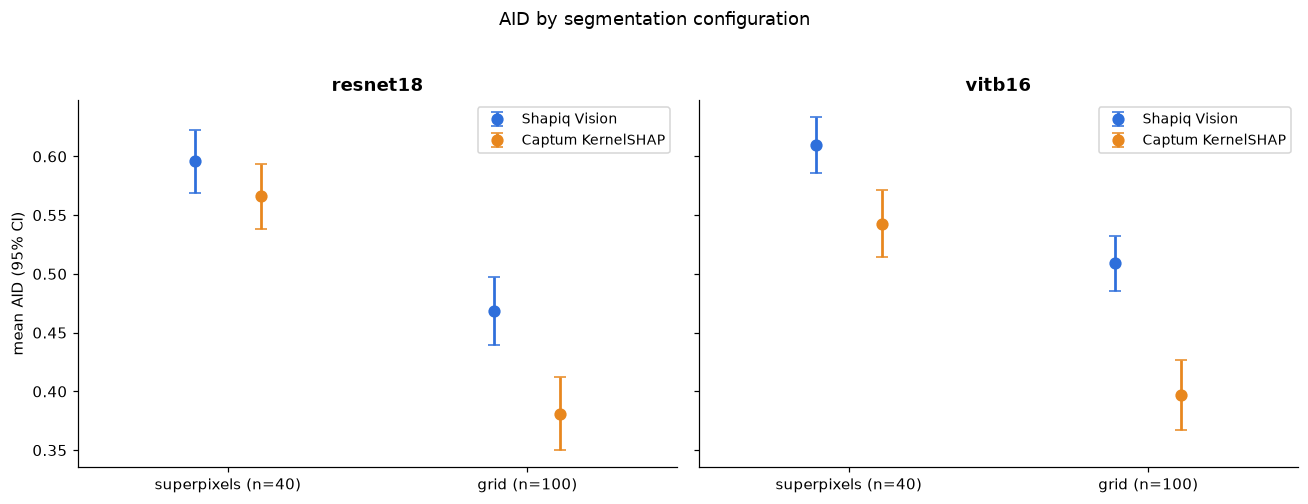

In [17]:
CONFIGS = [("superpixels", 40), ("grid", 100)]
xpos, width = np.arange(len(CONFIGS)), 0.22

fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4.4), sharey=True)
axes = np.atleast_1d(axes)

for ax, model_name in zip(axes, MODELS):
    for j, method in enumerate(METHODS):
        means, cis = [], []
        for seg, n in CONFIGS:
            vals = df.query("model == @model_name and method == @method and segmentation == @seg and n_segments == @n").aid
            means.append(vals.mean())
            cis.append(1.96 * vals.sem())
        ax.errorbar(xpos + (j - 0.5) * width, means, yerr=cis, color=COLOR[method],
                    marker="o", ls="none", ms=7, capsize=4, lw=1.8, label=LABEL[method])

    ax.set_xticks(xpos, [f"{seg} (n={n})" for seg, n in CONFIGS])
    ax.set_xlim(-0.5, len(CONFIGS) - 0.5)
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

axes[0].set_ylabel("mean AID (95% CI)")
fig.suptitle("AID by segmentation configuration", y=1.03)
plt.tight_layout()
plt.show()

### Summary table

In [15]:
summary = df.pivot_table(index=["model", "segmentation", "n_segments"], columns="method", values="aid", aggfunc="mean").round(3)
summary = summary[METHODS]
print(summary)

for model_name in MODELS:
    hero = df.query("model == @model_name and segmentation == @HERO_SEG and n_segments == @HERO_N")
    piv = hero.pivot_table(index="image", columns="method", values="aid").dropna()
    for m1, m2 in pairs:
        close = (abs(piv[m1] - piv[m2]) < 0.05).mean()
        print(f"[{model_name}] {LABEL[m1]} vs {LABEL[m2]}: {close:.0%} of images agree within 0.05 AID")

method                            shapiq_vision  kernel_shap
model    segmentation n_segments                            
resnet18 grid         100                 0.468        0.381
         superpixels  40                  0.596        0.566
vitb16   grid         100                 0.509        0.397
         superpixels  40                  0.610        0.543
[resnet18] Shapiq Vision vs Captum KernelSHAP: 56% of images agree within 0.05 AID
[vitb16] Shapiq Vision vs Captum KernelSHAP: 43% of images agree within 0.05 AID
